In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load data
train = pd.read_csv('../data/raw/train.csv')
test = pd.read_csv('../data/raw/test.csv')  # for final submission simulation

# Quick look
print(train.shape)
print(train.info())
print(train.describe(include='all'))
print(train.head())

(1460, 81)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          91 non-null     object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  Condition2     1460 non-null   object 
 15  BldgType       1460 non-null   object 
 16  HouseStyle     1460 non-null   object 
 17  OverallQual    1460 non-null   int64  
 1

## Exploratory Data Analysis (EDA)

### Univariate Analysis

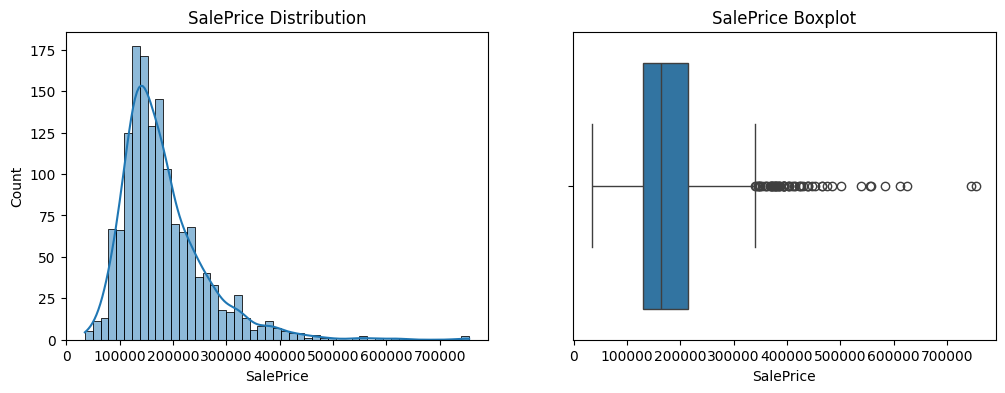

In [2]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(train['SalePrice'], kde=True, ax=ax[0])
ax[0].set_title('SalePrice Distribution')
sns.boxplot(x=train['SalePrice'], ax=ax[1])
ax[1].set_title('SalePrice Boxplot')
plt.savefig('../reports/figures/target_dist.png')

### Multivariate Analysis

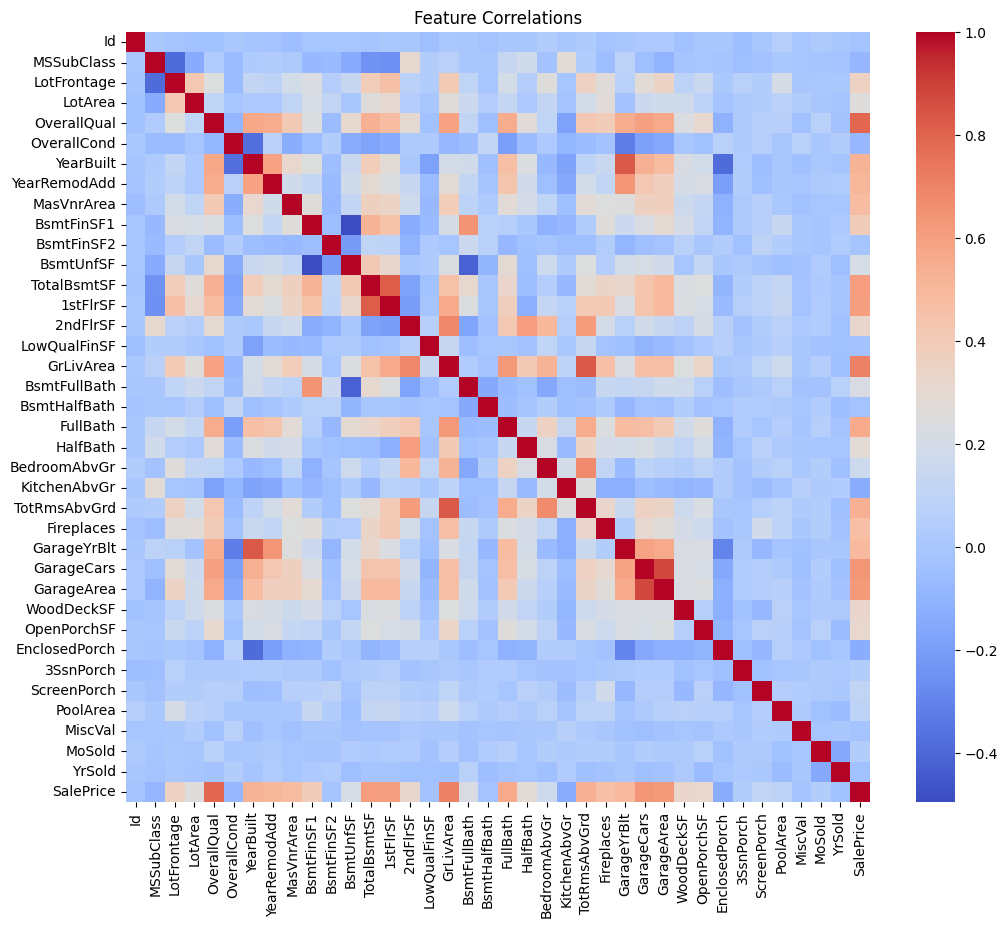

In [3]:
num_cols = train.select_dtypes(include=[np.number]).columns
corr = train[num_cols].corr()
plt.figure(figsize=(12, 10))
sns.heatmap(corr, annot=False, cmap='coolwarm')
plt.title('Feature Correlations')
plt.savefig('../reports/figures/corr_matrix.png')

**Top correlations with target:**

In [4]:
corr_target = corr['SalePrice'].sort_values(ascending=False)
print(corr_target.head(10))

SalePrice       1.000000
OverallQual     0.790982
GrLivArea       0.708624
GarageCars      0.640409
GarageArea      0.623431
TotalBsmtSF     0.613581
1stFlrSF        0.605852
FullBath        0.560664
TotRmsAbvGrd    0.533723
YearBuilt       0.522897
Name: SalePrice, dtype: float64


### Missing Data
Document observations: e.g., PoolQC has >99% missing – likely means "no pool". Alley, Fence, MiscFeature similarly. Some numerical features like LotFrontage have meaningful missing (impute later).

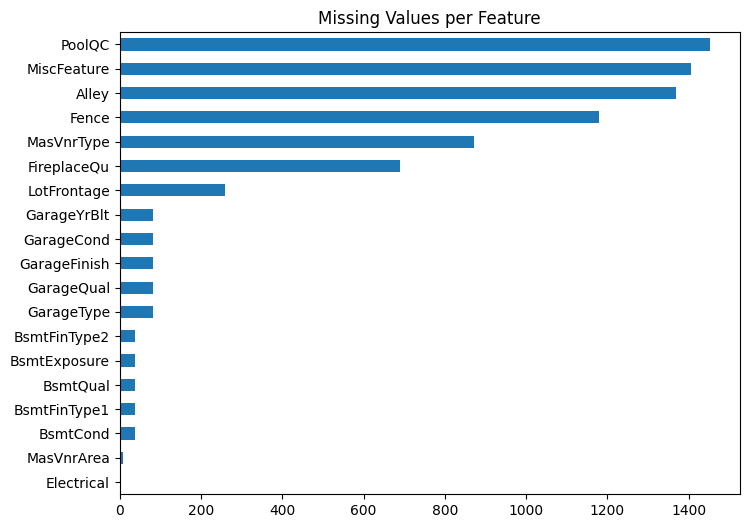

In [5]:
missing = train.isnull().sum()
missing = missing[missing > 0].sort_values()
missing.plot(kind='barh', figsize=(8, 6))
plt.title('Missing Values per Feature')
plt.savefig('../reports/figures/missing.png')

## Outlier Detection and Treatment

### Visual Inspection with Boxplots

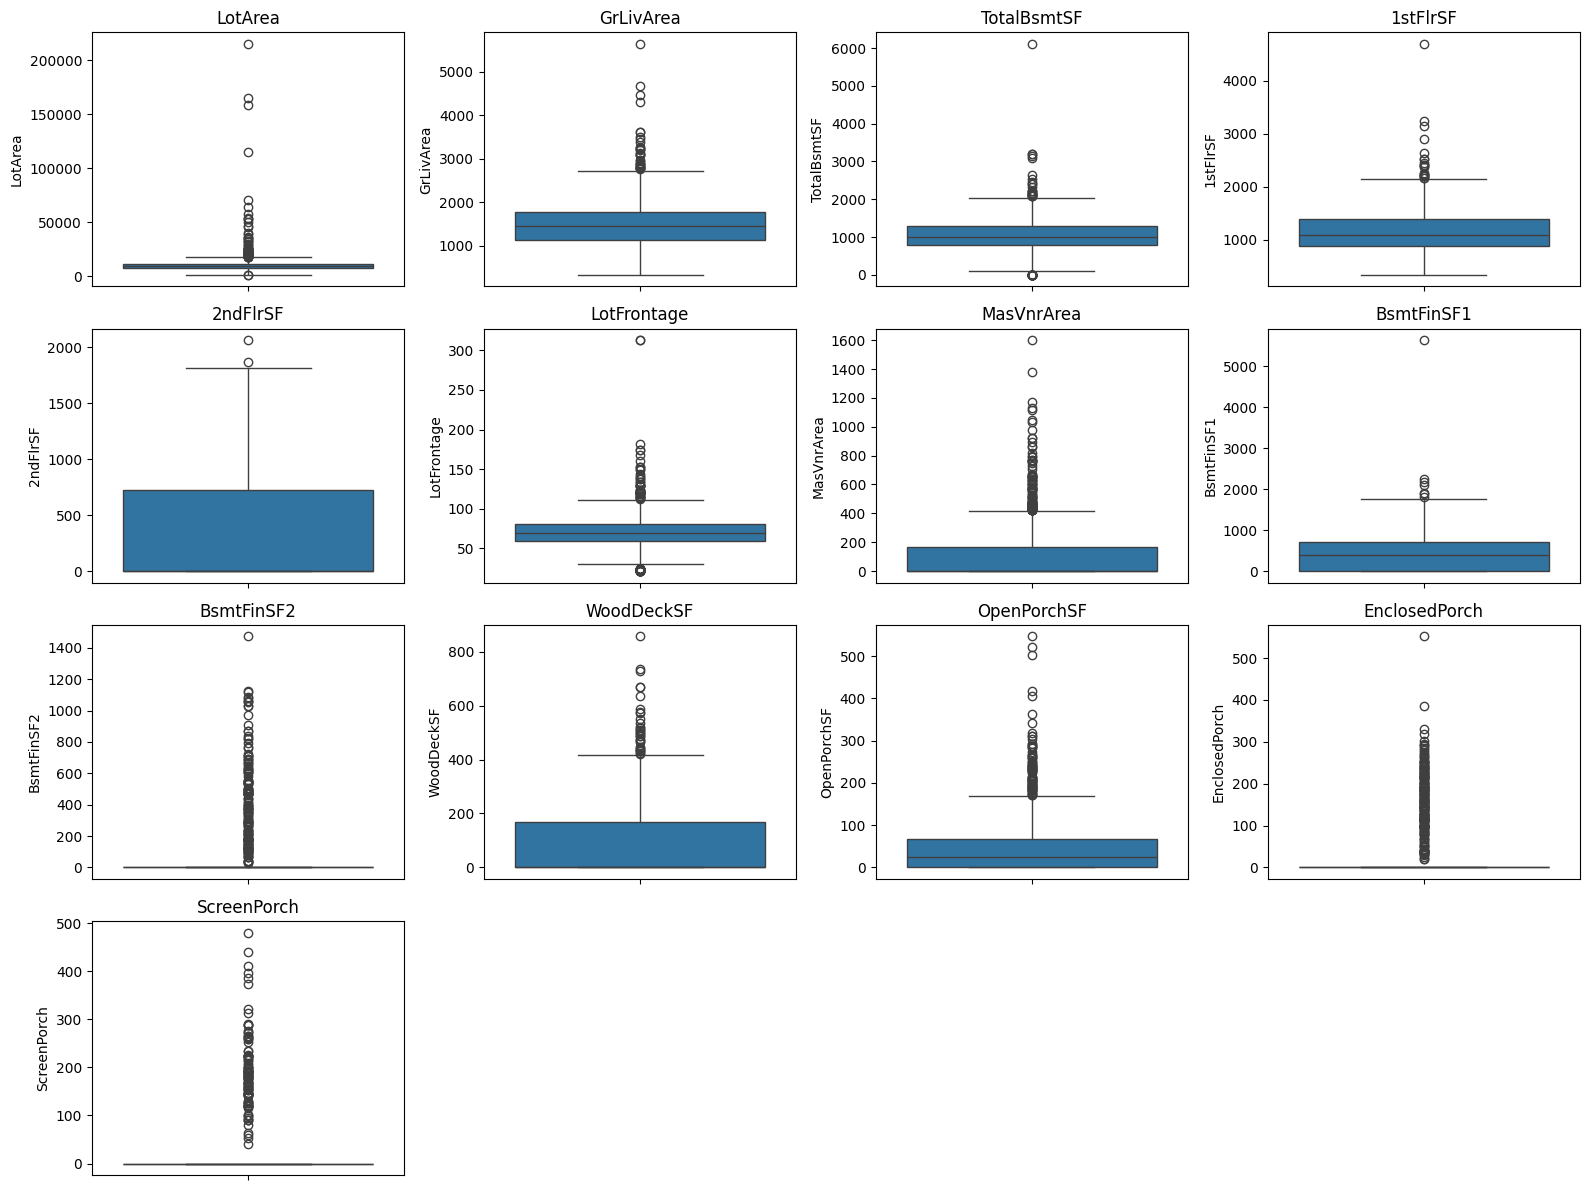

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load data
train = pd.read_csv('../data/raw/train.csv')

# Select numerical features (excluding target)
num_cols = train.select_dtypes(include=[np.number]).columns.drop('SalePrice')

# Plot boxplots for a subset of important features
important_num = ['LotArea', 'GrLivArea', 'TotalBsmtSF', '1stFlrSF', '2ndFlrSF', 
                 'LotFrontage', 'MasVnrArea', 'BsmtFinSF1', 'BsmtFinSF2', 
                 'WoodDeckSF', 'OpenPorchSF', 'EnclosedPorch', 'ScreenPorch']

# Adjust layout
fig, axes = plt.subplots(nrows=4, ncols=4, figsize=(16, 12))
axes = axes.flatten()

for i, col in enumerate(important_num):
    if i < len(axes):
        sns.boxplot(y=train[col], ax=axes[i])
        axes[i].set_title(col)
    else:
        break

# Hide empty subplots
for j in range(i+1, len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.savefig('../reports/figures/outliers_boxplots.png', dpi=100)
plt.show()

### Statistical Methods: IQR and Z-Score

**IQR Method:**

In [7]:
def detect_outliers_iqr(data, feature, multiplier=1.5):
    Q1 = data[feature].quantile(0.25)
    Q3 = data[feature].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - multiplier * IQR
    upper_bound = Q3 + multiplier * IQR
    outliers = data[(data[feature] < lower_bound) | (data[feature] > upper_bound)]
    return outliers, lower_bound, upper_bound

# Example for GrLivArea
outliers_grliv, lb_grliv, ub_grliv = detect_outliers_iqr(train, 'GrLivArea')
print(f"GrLivArea outliers count: {len(outliers_grliv)}")
print(f"Lower bound: {lb_grliv:.2f}, Upper bound: {ub_grliv:.2f}")

GrLivArea outliers count: 31
Lower bound: 158.62, Upper bound: 2747.62


**Z-Score Method (assuming normality):**

In [8]:
from scipy import stats

z_scores = np.abs(stats.zscore(train['GrLivArea'].dropna()))
threshold = 3
outliers_z = train['GrLivArea'].iloc[np.where(z_scores > threshold)]
print(f"GrLivArea outliers (z-score >3): {len(outliers_z)}")

GrLivArea outliers (z-score >3): 16


### Investigate Relationship with Target

**Observations:**

For GrLivArea > 4000, there are a few points with relatively lower SalePrice – these might be anomalies or properties with other characteristics. Check if they are errors (e.g., data entry) or genuine.

For LotArea, some extremely large lots (>100,000 sq ft) might be legitimate (e.g., farms), but they could also be outliers.

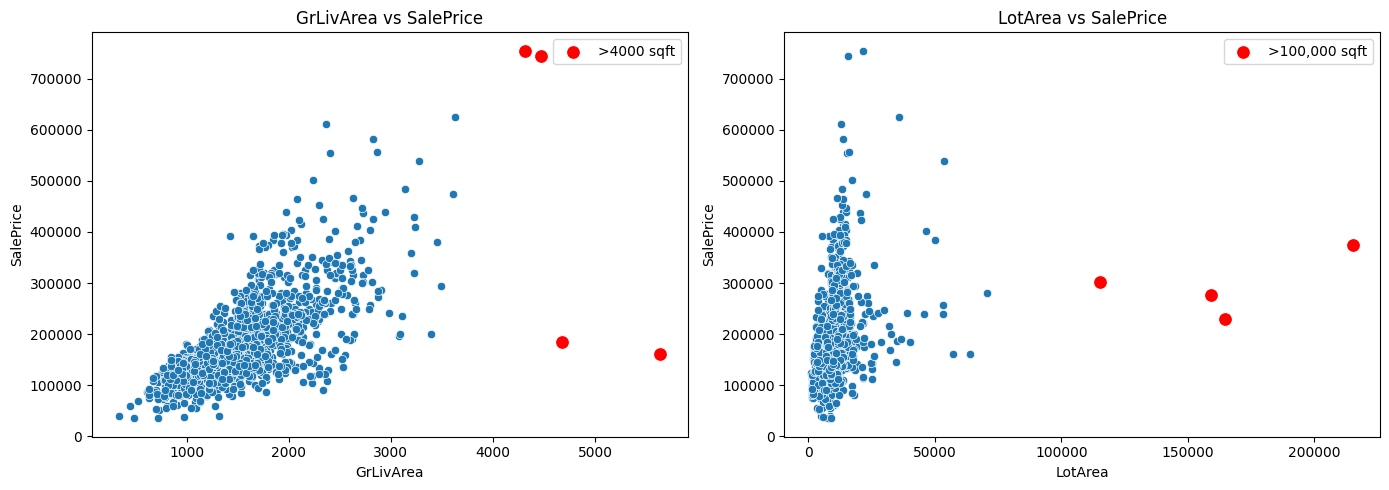

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Scatter plot GrLivArea vs SalePrice
sns.scatterplot(x='GrLivArea', y='SalePrice', data=train, ax=axes[0])
axes[0].set_title('GrLivArea vs SalePrice')

# Highlight potential outliers (e.g., GrLivArea > 4000)
outliers_high_grliv = train[train['GrLivArea'] > 4000]
sns.scatterplot(x='GrLivArea', y='SalePrice', data=outliers_high_grliv, 
                color='red', s=100, ax=axes[0], label='>4000 sqft')

# Scatter plot LotArea vs SalePrice
sns.scatterplot(x='LotArea', y='SalePrice', data=train, ax=axes[1])
axes[1].set_title('LotArea vs SalePrice')

# Highlight extreme LotArea (e.g., >100,000)
outliers_lot = train[train['LotArea'] > 100000]
sns.scatterplot(x='LotArea', y='SalePrice', data=outliers_lot, 
                color='red', s=100, ax=axes[1], label='>100,000 sqft')

plt.tight_layout()
plt.savefig('../reports/figures/outliers_scatter.png', dpi=100)
plt.show()

### Decision Making: Cap or Remove?

**Common strategies:**

1. Remove if clearly erroneous or extreme and you have enough data.
2. Cap (Winsorize) – replace extreme values with a specified percentile (e.g., 99th) to reduce impact.
3. Leave as is if they are genuine and you plan to use tree-based models (robust to outliers).

For House Prices, many Kaggle solutions cap GrLivArea and LotArea at reasonable thresholds. Use domain knowledge and explore further:

In [10]:
# Check records with GrLivArea > 4000
train[train['GrLivArea'] > 4000][['Id', 'GrLivArea', 'SalePrice', 'OverallQual', 'Neighborhood']]

,Id,GrLivArea,SalePrice,OverallQual,Neighborhood
523,524,4676,184750,10,Edwards
691,692,4316,755000,10,NoRidge
1182,1183,4476,745000,10,NoRidge
1298,1299,5642,160000,10,Edwards


If you find that the very large houses are in expensive neighborhoods with high quality, they might be genuine mansions. If they have low SalePrice given their size, they could be data errors.

Example decision (based on common practice):

Cap GrLivArea at 4000 (or 99th percentile) and LotArea at 100,000.

Remove the one property with GrLivArea > 5000 and SalePrice < 200,000 (if it's an obvious outlier).

**Implementation in preprocessing:(to be added in preprocess.py or a notebook cell)**

In [11]:
from scipy.stats.mstats import winsorize

def treat_outliers(df, columns, limits=(0.01, 0.01)):
    """
    Winsorize specified columns.
    limits: (lower_fraction, upper_fraction) to cap.
    """
    df_treated = df.copy()
    for col in columns:
        df_treated[col] = winsorize(df[col], limits=limits)
    return df_treated

# Example: cap top and bottom 1% of GrLivArea and LotArea
cols_to_cap = ['GrLivArea', 'LotArea']
train_capped = treat_outliers(train, cols_to_cap, limits=(0.01, 0.01))

Alternatively, you can manually cap using np.where:

In [12]:
train['GrLivArea_capped'] = np.where(train['GrLivArea'] > 4000, 4000, train['GrLivArea'])

| Note: If you cap, do it after train/test split to avoid data leakage? Actually, capping based on full training data is acceptable as it's part of preprocessing; just ensure you apply the same thresholds to test data. You can compute percentiles from training and use them to transform both sets.

## Document Findings

### Outlier Analysis
GrLivArea: Identified 4 properties with >4000 sq ft. Three have high SalePrice (consistent with size), one (Id = 524) has low SalePrice relative to size. We'll cap GrLivArea at 4000 to reduce leverage.

LotArea: Several properties >100,000 sq ft. These appear to be legitimate large lots (e.g., in rural areas). We'll keep them but may consider log transformation later.

Decision: Apply winsorization to GrLivArea and LotArea at the 99th percentile. This will be implemented in the preprocessing pipeline.